<a href="https://colab.research.google.com/github/Dipu1764/Data-analyst-internship-task-1/blob/DATA/Data_analyst_internship_task_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

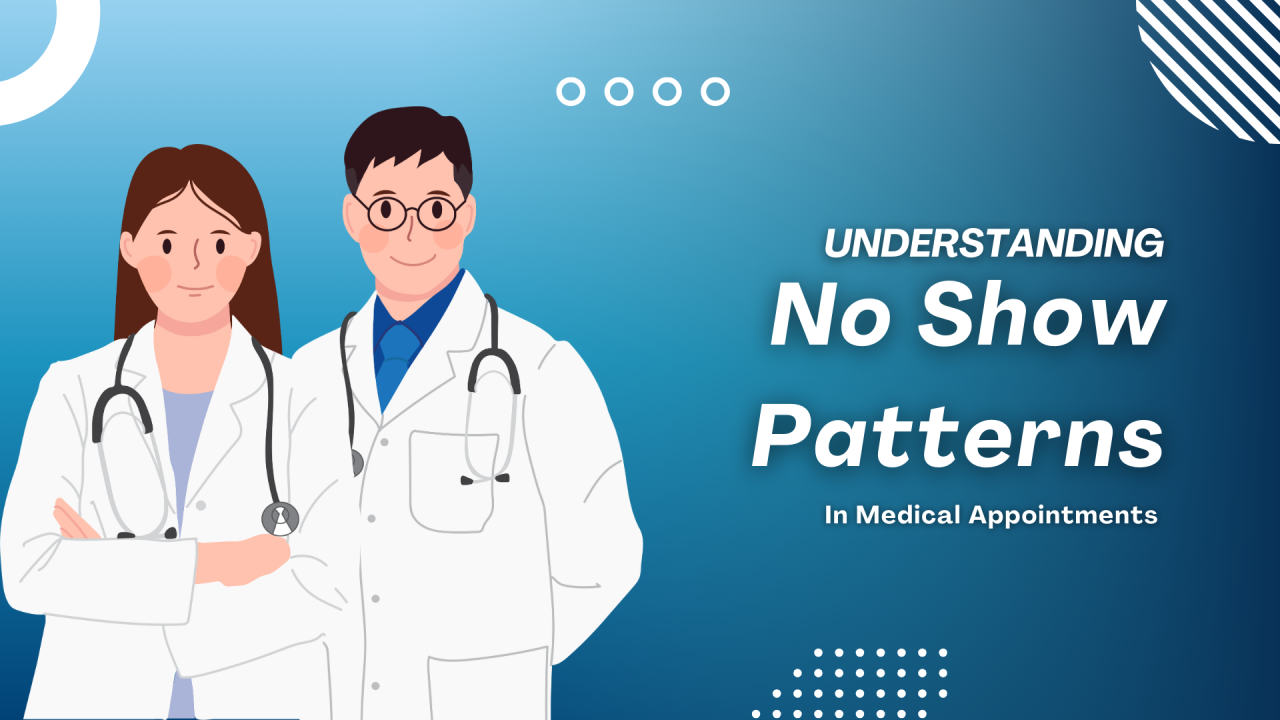

# **Importing librarys**

In [60]:
#importing librarys
import numpy as np
import pandas as pd

# **Load the datase**

In [61]:
#Load the dataset & show first 5 row and columns
Medical_data = pd.read_csv("/content/medical-appointments-no-show-en.csv")
Medical_data.head()

,specialty,appointment_time,gender,appointment_date,no_show,no_show_reason,disability,date_of_birth,entry_service_date,city,...,over_60_years_old,patient_needs_companion,average_temp_day,average_rain_day,max_temp_day,max_rain_day,rainy_day_before,storm_day_before,rain_intensity,heat_intensity
0,physiotherapy,13:20,M,09/09/2021,yes,surto,NaN,NaN,NaN,NaN,...,0,0,20.75,0.01,23.7,0.2,1,1,no_rain,mild
1,psychotherapy,13:20,M,09/09/2021,no,NaN,NaN,NaN,NaN,NaN,...,0,0,20.75,0.01,23.7,0.2,1,1,no_rain,mild
2,speech therapy,13:20,F,09/09/2021,no,NaN,NaN,NaN,NaN,NaN,...,0,0,20.75,0.01,23.7,0.2,1,1,no_rain,mild
3,physiotherapy,13:20,F,09/09/2021,no,NaN,NaN,NaN,NaN,NaN,...,0,0,20.75,0.01,23.7,0.2,1,1,no_rain,mild
4,physiotherapy,14:00,M,09/09/2021,no,NaN,motor,10/10/1954,5/2/2020,B. CAMBORIU,...,1,1,20.75,0.01,23.7,0.2,1,1,no_rain,mild


# **Info, Shape, Columns, describe**

In [62]:
Medical_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49593 entries, 0 to 49592
Data columns (total 26 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   specialty                42139 non-null  object 
 1   appointment_time         49593 non-null  object 
 2   gender                   49593 non-null  object 
 3   appointment_date         49593 non-null  object 
 4   no_show                  49593 non-null  object 
 5   no_show_reason           1737 non-null   object 
 6   disability               44456 non-null  object 
 7   date_of_birth            39272 non-null  object 
 8   entry_service_date       44438 non-null  object 
 9   city                     44412 non-null  object 
 10  icd                      10717 non-null  object 
 11  appointment_month        49593 non-null  object 
 12  appointment_year         49593 non-null  int64  
 13  appointment_shift        49593 non-null  object 
 14  age                   

In [63]:
Medical_data.shape

(49593, 26)

In [36]:
Medical_data.columns

Index(['specialty', 'appointment_time', 'gender', 'appointment_date',
       'no_show', 'no_show_reason', 'disability', 'date_of_birth',
       'entry_service_date', 'city', 'icd', 'appointment_month',
       'appointment_year', 'appointment_shift', 'age', 'under_12_years_old',
       'over_60_years_old', 'patient_needs_companion', 'average_temp_day',
       'average_rain_day', 'max_temp_day', 'max_rain_day', 'rainy_day_before',
       'storm_day_before', 'rain_intensity', 'heat_intensity'],
      dtype='object')

In [64]:
Medical_data.describe()

,appointment_year,age,under_12_years_old,over_60_years_old,patient_needs_companion,average_temp_day,average_rain_day,max_temp_day,max_rain_day,rainy_day_before,storm_day_before
count,49593.000000,39243.000000,49593.000000,49593.000000,49593.000000,48577.000000,48577.000000,48577.000000,48577.000000,49593.000000,49593.000000
mean,2018.255076,18.522361,0.472446,0.071784,0.544230,19.748317,0.190119,23.961984,1.895687,0.981005,0.981005
std,1.736964,19.234999,0.499245,0.258133,0.498045,3.428767,0.452214,3.819804,4.445412,0.136507,0.136507
min,2016.000000,2.000000,0.000000,0.000000,0.000000,8.940000,0.000000,13.300000,0.000000,0.000000,0.000000
25%,2017.000000,8.000000,0.000000,0.000000,0.000000,17.480000,0.000000,21.400000,0.000000,1.000000,1.000000
50%,2018.000000,11.000000,0.000000,0.000000,1.000000,20.060000,0.010000,23.900000,0.200000,1.000000,1.000000
75%,2019.000000,15.000000,1.000000,0.000000,1.000000,22.120000,0.150000,26.500000,1.600000,1.000000,1.000000
max,2022.000000,110.000000,1.000000,1.000000,1.000000,28.010000,4.770000,35.400000,45.000000,1.000000,1.000000


# **Identify & Handle Missing Values**

In [65]:
# Rename column headers (lowercase, replace spaces with underscores)
Medical_data.columns = Medical_data.columns.str.strip().str.lower().str.replace(' ', '_')

# **Removed Duplicate Rows**

In [66]:
# Remove duplicate rows
Medical_data = Medical_data.drop_duplicates()

In [67]:
# Handle missing values
# Fill numerical column 'age' with median
if 'age' in Medical_data.columns:
    Medical_data['age'] = Medical_data['age'].fillna(Medical_data['age'].median())

In [68]:
# Fill gender and city with 'Unknown'
for col in ['gender', 'city']:
    if col in Medical_data.columns:
        Medical_data[col] = Medical_data[col].fillna('Unknown')

In [70]:
# Convert date columns and fill forward for missing values
for date_col in ['appointment_date', 'date_of_birth', 'entry_service_date']:
    if date_col in Medical_data.columns:
        Medical_data[date_col] = pd.to_datetime(Medical_data[date_col], errors='coerce')
        Medical_data[date_col] = Medical_data[date_col].fillna(method='ffill')

# Drop any rows still missing required date fields
Medical_data = Medical_data.dropna(subset=['appointment_date'])

/tmp/ipython-input-2626443843.py:5: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  Medical_data[date_col] = Medical_data[date_col].fillna(method='ffill')
/tmp/ipython-input-2626443843.py:5: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  Medical_data[date_col] = Medical_data[date_col].fillna(method='ffill')
/tmp/ipython-input-2626443843.py:5: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  Medical_data[date_col] = Medical_data[date_col].fillna(method='ffill')


# **Standardized Text Values**

In [71]:
# Standardize text values
if 'gender' in Medical_data.columns:
    Medical_data['gender'] = Medical_data['gender'].str.strip().str.upper()
    Medical_data['gender'] = Medical_data['gender'].replace({'F': 'FEMALE', 'M': 'MALE', 'UNKNOWN': 'UNKNOWN'})

if 'city' in Medical_data.columns:
    Medical_data['city'] = Medical_data['city'].str.strip().str.title()

if 'no_show' in Medical_data.columns:
    Medical_data['no_show'] = Medical_data['no_show'].str.strip().str.lower()
    Medical_data['no_show'] = Medical_data['no_show'].map({'yes': 1, 'no': 0})

# **Fix data types**

In [72]:
# Fix data types
# Convert 'age' to integer
if 'age' in Medical_data.columns:
    Medical_data['age'] = Medical_data['age'].astype(int)

# Convert weather/temp columns to float
for col in Medical_data.columns:
    if 'temp' in col or 'humidity' in col or 'wind_speed' in col:
        Medical_data[col] = pd.to_numeric(Medical_data[col], errors='coerce')


# **Final Dataset Stats**

In [73]:
# Final cleaned dataset
Medical_data.reset_index(drop=True, inplace=True)

# Optionally save cleaned dataset
Medical_data.to_csv("cleaned_medical_appointments.csv", index=False)

print("Dataset cleaned and saved as 'cleaned_medical_appointments.csv'")

Dataset cleaned and saved as 'cleaned_medical_appointments.csv'
